# Analyse Exploratoire des Données (EDA) — Prédiction de retard de paiement

**Objectif de ce notebook :** comprendre les données brutes avant de construire quoi que ce soit
(feature engineering, modèle, pipeline MLOps). On avance étape par étape :

1. Chargement des données et aperçu général
2. Nettoyage des noms de colonnes
3. Vérification des doublons
4. Vérification des valeurs manquantes (null)
5. Vérification de la cohérence des valeurs (valeurs aberrantes / catégories invalides)
6. Analyse de l'équilibre de la variable cible (classe déséquilibrée ou non ?)
7. Statistiques descriptives des variables numériques
8. Distributions des variables clés
9. Corrélations avec la cible
10. Synthèse et prochaines étapes

**Dataset :** [Default of Credit Card Clients Dataset (UCI)](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)
— 30 000 clients de cartes de crédit à Taïwan, avec comme cible `default payment next month`
(1 = le client a fait défaut / retard le mois suivant, 0 = non).


## 1. Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "../default of credit card clients.xls"


Le fichier Excel a un en-tête particulier : la **première ligne** contient des codes génériques
(`X1`, `X2`, ...) et la **deuxième ligne** contient les vrais noms de colonnes (`LIMIT_BAL`, `SEX`, ...).
On indique donc `header=1` pour utiliser la deuxième ligne comme noms de colonnes.

In [2]:
df = pd.read_excel(DATA_PATH, sheet_name=0, header=1)
print("Dimensions (lignes, colonnes) :", df.shape)
df.head()


Dimensions (lignes, colonnes) : (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Nettoyage des noms de colonnes

- `ID` est l'identifiant client (à exclure des features plus tard).
- `PAY_0` est en réalité le retard de paiement de septembre (le doc UCI numérote `PAY_1..PAY_6`
  mais le fichier contient `PAY_0` au lieu de `PAY_1`). On le renomme pour rester cohérent.
- La cible `default payment next month` est renommée en `DEFAULT` pour plus de simplicité.


In [3]:
df = df.rename(columns={
    "PAY_0": "PAY_1",
    "default payment next month": "DEFAULT",
})
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.dtypes


['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


ID           int64
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_1        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
DEFAULT      int64
dtype: object

## 3. Vérification des doublons

Deux niveaux à vérifier :
- des **lignes strictement identiques** (toutes colonnes, y compris ID) → anomalie de collecte.
- des **ID clients dupliqués** (même client apparaissant plusieurs fois) → à part, car ID est censé être unique.


In [4]:
n_full_dup = df.duplicated().sum()
print(f"Lignes entièrement dupliquées : {n_full_dup}")

n_id_dup = df["ID"].duplicated().sum()
print(f"ID clients dupliqués : {n_id_dup}")
print(f"ID uniques : {df['ID'].nunique()} / {len(df)} lignes")


Lignes entièrement dupliquées : 0
ID clients dupliqués : 0
ID uniques : 30000 / 30000 lignes


Si des doublons existent, on les affiche pour inspection avant de décider de les supprimer :

In [5]:
if n_full_dup > 0:
    display(df[df.duplicated(keep=False)].sort_values("ID"))
else:
    print("Aucune ligne dupliquée détectée.")


Aucune ligne dupliquée détectée.


## 4. Vérification des valeurs manquantes (null)

On regarde le nombre et le pourcentage de valeurs manquantes par colonne.


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missing_summary = missing_summary[missing_summary["n_missing"] > 0].sort_values("n_missing", ascending=False)

if missing_summary.empty:
    print("Aucune valeur manquante (NaN) dans le dataset.")
else:
    display(missing_summary)


Aucune valeur manquante (NaN) dans le dataset.


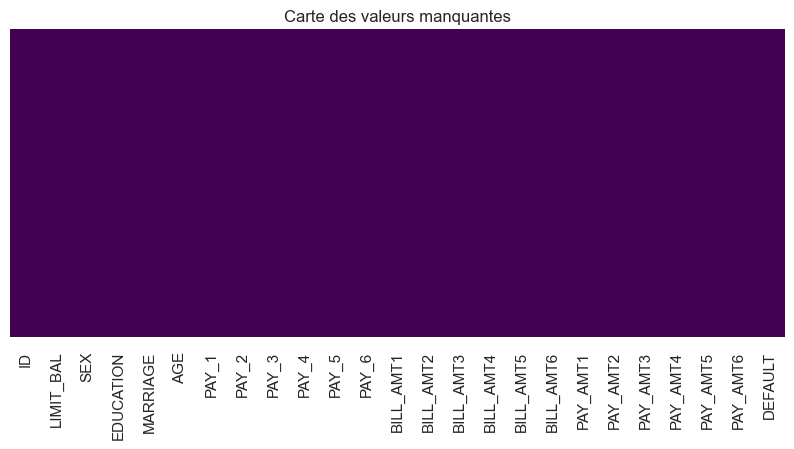

In [7]:
# Visualisation rapide (utile même si vide, pour garder le réflexe sur d'autres jeux de données)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Carte des valeurs manquantes")
plt.show()


## 5. Cohérence des valeurs (valeurs aberrantes / catégories invalides)

L'absence de `NaN` ne veut pas dire que les données sont propres : certaines variables catégorielles
ont des **codes non documentés**. D'après la documentation UCI :

- `SEX` : 1 = homme, 2 = femme
- `EDUCATION` : 1 = graduate school, 2 = university, 3 = high school, 4 = others
  → on va vérifier s'il existe des valeurs **0, 5, 6** (non documentées)
- `MARRIAGE` : 1 = marié, 2 = célibataire, 3 = autre
  → on va vérifier s'il existe une valeur **0** (non documentée)
- `PAY_1..PAY_6` : -2/-1/0 = pas de retard (selon convention), 1-9 = mois de retard


In [8]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())
    print()


--- SEX ---
SEX
1    11888
2    18112
Name: count, dtype: int64

--- EDUCATION ---
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

--- MARRIAGE ---
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64



In [9]:
print("Valeurs prises par PAY_1..PAY_6 :")
pay_cols = [f"PAY_{i}" for i in range(1, 7)]
for col in pay_cols:
    print(col, sorted(df[col].unique()))


Valeurs prises par PAY_1..PAY_6 :
PAY_1 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


On regarde aussi les montants (`LIMIT_BAL`, `BILL_AMT*`, `PAY_AMT*`) : des valeurs négatives
sur les montants facturés (`BILL_AMT`) peuvent être normales (crédit en faveur du client), mais
`LIMIT_BAL` négatif ou nul serait suspect.

In [10]:
print("LIMIT_BAL <= 0 :", (df["LIMIT_BAL"] <= 0).sum())
print("AGE min/max :", df["AGE"].min(), "/", df["AGE"].max())

bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
print("\nMontants négatifs par colonne :")
print(df[bill_cols + pay_amt_cols].lt(0).sum())


LIMIT_BAL <= 0 : 0
AGE min/max : 21 / 79

Montants négatifs par colonne :
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
PAY_AMT1       0
PAY_AMT2       0
PAY_AMT3       0
PAY_AMT4       0
PAY_AMT5       0
PAY_AMT6       0
dtype: int64


## 6. La variable cible est-elle équilibrée ? (`DEFAULT`)

C'est une étape **critique** avant de choisir une stratégie de modélisation : si la classe
"défaut de paiement" est minoritaire, il faudra adapter la métrique d'évaluation (pas juste
l'accuracy) et éventuellement la stratégie d'entraînement (rééquilibrage, poids de classe...).


In [11]:
counts = df["DEFAULT"].value_counts().sort_index()
pct = (counts / len(df) * 100).round(2)
balance_df = pd.DataFrame({"count": counts, "pct": pct})
balance_df.index = balance_df.index.map({0: "0 - Pas de défaut", 1: "1 - Défaut"})
display(balance_df)

ratio = counts[0] / counts[1]
print(f"Ratio classe majoritaire / classe minoritaire : {ratio:.2f} : 1")


,count,pct
DEFAULT,,
0 - Pas de défaut,23364,77.88
1 - Défaut,6636,22.12


Ratio classe majoritaire / classe minoritaire : 3.52 : 1


C:\Users\hp\AppData\Local\Temp\ipykernel_18388\162482237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="DEFAULT", data=df, ax=axes[0], palette="Set2")
C:\Users\hp\AppData\Local\Temp\ipykernel_18388\162482237.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["0 - Pas de défaut", "1 - Défaut"])


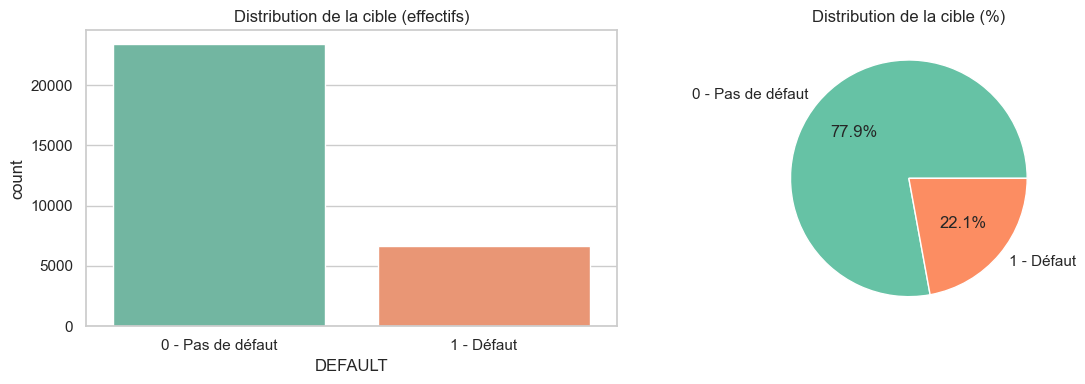

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="DEFAULT", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Distribution de la cible (effectifs)")
axes[0].set_xticklabels(["0 - Pas de défaut", "1 - Défaut"])

axes[1].pie(counts, labels=["0 - Pas de défaut", "1 - Défaut"], autopct="%1.1f%%",
            colors=sns.color_palette("Set2"))
axes[1].set_title("Distribution de la cible (%)")

plt.tight_layout()
plt.show()


**Interprétation :** un ratio proche de 1:1 indique un jeu de données équilibré. Un ratio
supérieur à environ 3:1 ou 4:1 est généralement considéré comme un déséquilibre significatif à
prendre en compte (métriques adaptées comme F1/PR-AUC, pondération des classes, sur/sous-échantillonnage, etc.).
On commente ce chiffre concrètement une fois le résultat affiché ci-dessus.

## 7. Statistiques descriptives des variables numériques

In [13]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


On sépare aussi les variables catégorielles (`SEX`, `EDUCATION`, `MARRIAGE`) des variables continues pour une lecture plus claire :

In [14]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols = ["LIMIT_BAL", "AGE"] + bill_cols + pay_amt_cols

print("Variables catégorielles :", cat_cols)
print("Variables numériques continues :", num_cols)
print("Variables ordinales (retard de paiement) :", pay_cols)


Variables catégorielles : ['SEX', 'EDUCATION', 'MARRIAGE']
Variables numériques continues : ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Variables ordinales (retard de paiement) : ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


## 8. Distributions des variables clés

On regarde la distribution de `LIMIT_BAL` et `AGE`, globalement et par classe cible, pour repérer
d'éventuelles différences entre clients en défaut et non en défaut.


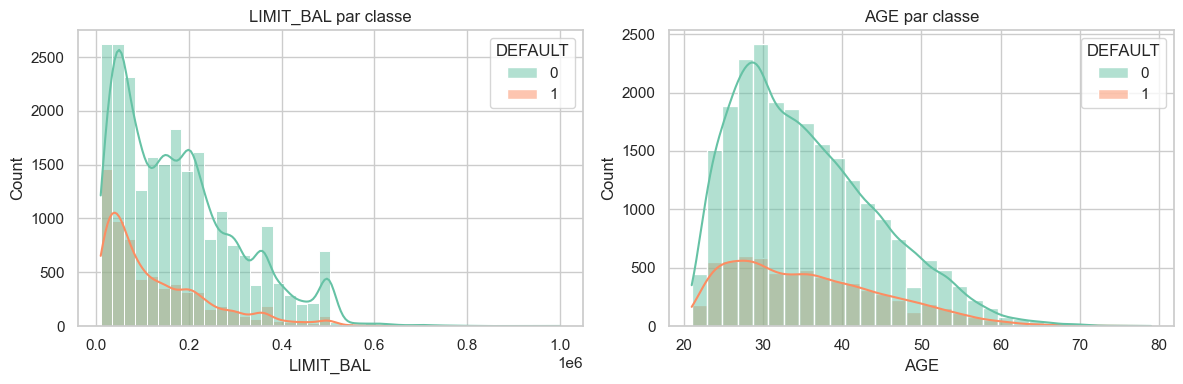

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df, x="LIMIT_BAL", hue="DEFAULT", bins=40, kde=True, ax=axes[0], palette="Set2")
axes[0].set_title("LIMIT_BAL par classe")

sns.histplot(df, x="AGE", hue="DEFAULT", bins=30, kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("AGE par classe")

plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_18388\2374420951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="DEFAULT", y="LIMIT_BAL", data=df, palette="Set2")


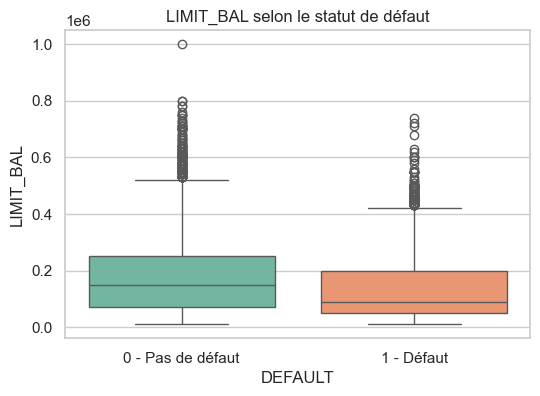

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="DEFAULT", y="LIMIT_BAL", data=df, palette="Set2")
plt.xticks([0, 1], ["0 - Pas de défaut", "1 - Défaut"])
plt.title("LIMIT_BAL selon le statut de défaut")
plt.show()


## 9. Corrélations avec la cible

Une matrice de corrélation (Pearson) donne une première idée des variables les plus liées à la cible
— à interpréter avec prudence puisque plusieurs variables sont catégorielles/ordinales et la relation
peut être non-linéaire.


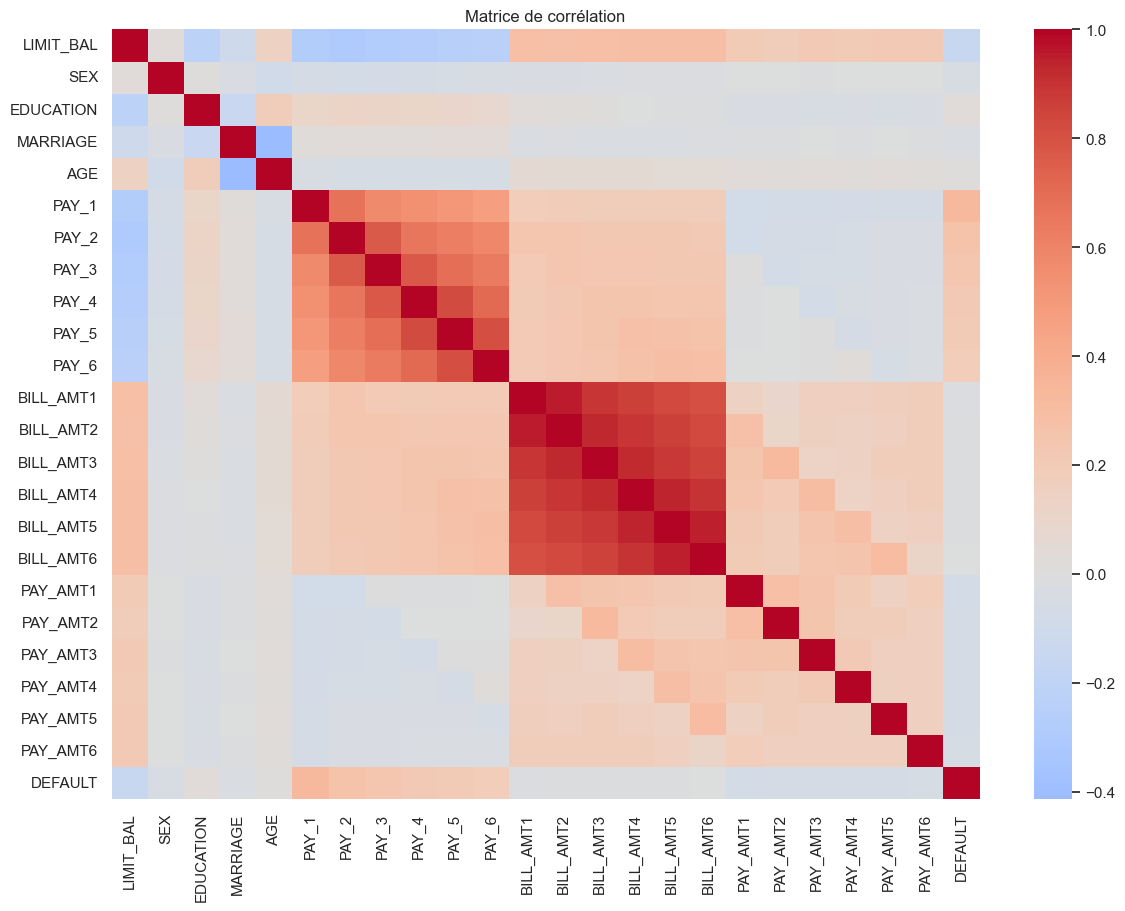

In [17]:
corr = df.drop(columns=["ID"]).corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation")
plt.show()


In [18]:
corr_target = corr["DEFAULT"].drop("DEFAULT").sort_values(key=abs, ascending=False)
print("Corrélation avec DEFAULT (triée par valeur absolue) :")
corr_target


Corrélation avec DEFAULT (triée par valeur absolue) :


PAY_1        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
SEX         -0.039961
EDUCATION    0.028006
MARRIAGE    -0.024339
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: DEFAULT, dtype: float64

## 10. Synthèse

À compléter après exécution du notebook, par exemple :

- [ ] Nombre de lignes / colonnes, doublons trouvés (et décision : suppression ou non)
- [ ] Valeurs manquantes trouvées (et stratégie d'imputation si besoin)
- [ ] Catégories invalides détectées (`EDUCATION` 0/5/6, `MARRIAGE` 0) et décision de traitement
- [ ] Niveau de déséquilibre de la cible et implication sur la métrique/stratégie de modélisation
- [ ] Variables les plus corrélées à la cible → pistes de feature engineering

**Prochaine étape du pipeline MLOps :** une fois ces constats validés, on passera à la définition
d'un pipeline de préparation des données (nettoyage, encodage, split train/test) dans un script
réutilisable (hors notebook), avant l'entraînement du modèle.


# Partie 2 — Nettoyage, Feature Engineering et Stratégies de rééquilibrage

Cette partie applique les décisions discutées après l'EDA :

1. Nettoyage des codes non documentés (`EDUCATION`, `MARRIAGE`)
2. Feature engineering (ratios métier, agrégats, tendances) + vérification de la corrélation avec la cible
3. Préparation des données pour la modélisation (split train/test stratifié)
4. Comparaison empirique de plusieurs modèles × plusieurs stratégies de gestion du déséquilibre
5. Choix de la meilleure combinaison + calibration du seuil de décision
6. Synthèse et recommandations pour le pipeline MLOps


## 11. Nettoyage des codes non documentés

Rappel du constat de la partie 5 : `EDUCATION` contient des codes 0/5/6 (345 lignes, 1.15%) et
`MARRIAGE` contient un code 0 (54 lignes, 0.18%), absents de la documentation UCI. Ce ne sont pas
des `NaN` — juste des catégories non prévues.

**Décision :** on ne supprime pas ces lignes (perte d'info inutile) et on n'impute pas par le mode
(ça supposerait une absence "au hasard", non vérifiée). Le schéma UCI prévoit déjà une catégorie
"autre" (`EDUCATION=4`, `MARRIAGE=3`) : on y fusionne les codes non documentés, après avoir vérifié
que leur taux de défaut n'est pas radicalement différent de la moyenne (ce qui justifierait de les
garder à part plutôt que de les diluer).


In [19]:
print("Taux de défaut moyen global : {:.2%}".format(df["DEFAULT"].mean()))
print()
print("Taux de défaut par valeur de EDUCATION :")
print(df.groupby("EDUCATION")["DEFAULT"].agg(["mean", "count"]))
print()
print("Taux de défaut par valeur de MARRIAGE :")
print(df.groupby("MARRIAGE")["DEFAULT"].agg(["mean", "count"]))


Taux de défaut moyen global : 22.12%

Taux de défaut par valeur de EDUCATION :
               mean  count
EDUCATION                 
0          0.000000     14
1          0.192348  10585
2          0.237349  14030
3          0.251576   4917
4          0.056911    123
5          0.064286    280
6          0.156863     51

Taux de défaut par valeur de MARRIAGE :
              mean  count
MARRIAGE                 
0         0.092593     54
1         0.234717  13659
2         0.209283  15964
3         0.260062    323


In [20]:
# Fusion des codes non documentés avec la catégorie "autre" déjà existante.
# EDUCATION : 0, 5, 6 -> 4 ("others")
# MARRIAGE  : 0 -> 3 ("other")
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("EDUCATION après nettoyage :")
print(df["EDUCATION"].value_counts().sort_index())
print()
print("MARRIAGE après nettoyage :")
print(df["MARRIAGE"].value_counts().sort_index())


EDUCATION après nettoyage :
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE après nettoyage :
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


## 12. Feature engineering

`BILL_AMT1..6` et `PAY_1..6` sont fortement corrélées **entre elles** (même solde/même
comportement d'un mois sur l'autre) : c'est de la multicolinéarité, pas un problème avec la cible
mais qui dilue l'importance des variables et instabilise les modèles linéaires. Plutôt que de
garder les 18 colonnes brutes mensuelles telles quelles, on les résume en ratios et agrégats qui
ont un sens métier direct — ce qui règle la redondance et enrichit le signal en même temps.

- **`utilization_rate`** : part du plafond de crédit utilisée ce mois-ci (`BILL_AMT1 / LIMIT_BAL`).
  Un client à 95% d'utilisation est plus risqué qu'un client à 20%.
- **`avg_utilization_rate`** : même idée, moyennée sur les 6 mois (tendance de fond plutôt qu'un
  instantané).
- **`payment_ratio_1..5`** : part de la facture du mois précédent réellement remboursée
  (`PAY_AMT_i / BILL_AMT_{i+1}`). Un ratio proche de 0 = le client ne rembourse presque rien.
- **`bill_trend`** : évolution du solde entre le mois le plus ancien et le plus récent
  (`BILL_AMT1 - BILL_AMT6`). Positif = endettement croissant.
- **`avg_bill_amt` / `avg_pay_amt`** : moyennes sur 6 mois du solde facturé et du montant remboursé.
- **`pay_delay_max`** : pire retard observé sur les 6 mois (souvent très prédictif, un incident
  grave même isolé compte plus que la moyenne).
- **`pay_delay_mean`** : sévérité moyenne du retard sur 6 mois.
- **`n_months_late`** : nombre de mois (sur 6) où le client a été en retard (`PAY_i > 0`).
- **`recent_vs_past_delay`** : le comportement récent (`PAY_1`) est-il pire que la moyenne
  historique (`PAY_2..6`) ? Capture une dynamique de dégradation/amélioration.
- **`ever_serious_delay`** : indicateur binaire — a-t-il déjà eu un retard sérieux (≥2 mois) ?

On garde par ailleurs `PAY_1`, `BILL_AMT1` et `PAY_AMT1` (le mois le plus récent, souvent le plus
informatif seul) en plus de ces agrégats.


In [21]:
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
pay_cols = [f"PAY_{i}" for i in range(1, 7)]

# 1. Taux d'utilisation du crédit (instantané + moyenne 6 mois)
df["utilization_rate"] = df["BILL_AMT1"] / (df["LIMIT_BAL"] + 1)
df["avg_utilization_rate"] = df[bill_cols].mean(axis=1) / (df["LIMIT_BAL"] + 1)

# 2. Taux de remboursement de la facture précédente
# PAY_AMT_i est payé au mois i pour éponger la facture du mois i+1 (BILL_AMT_{i+1}).
# BILL_AMT peut être négatif (crédit en faveur du client), voire valoir -1 pile : on plafonne le
# dénominateur à 0 avant le +1 pour ne jamais diviser par zéro (sinon inf, qui fait planter
# StandardScaler plus loin).
for i in range(1, 6):
    safe_bill = df[f"BILL_AMT{i+1}"].clip(lower=0)
    df[f"payment_ratio_{i}"] = df[f"PAY_AMT{i}"] / (safe_bill + 1)

# 3. Tendance du solde sur 6 mois
df["bill_trend"] = df["BILL_AMT1"] - df["BILL_AMT6"]

# 4. Historique de retard : sévérité, fréquence, dynamique récente
df["pay_delay_max"] = df[pay_cols].max(axis=1)
df["pay_delay_mean"] = df[pay_cols].mean(axis=1)
df["n_months_late"] = (df[pay_cols] > 0).sum(axis=1)
df["recent_vs_past_delay"] = df["PAY_1"] - df[pay_cols[1:]].mean(axis=1)
df["ever_serious_delay"] = (df["pay_delay_max"] >= 2).astype(int)

# 5. Moyennes globales sur 6 mois
df["avg_bill_amt"] = df[bill_cols].mean(axis=1)
df["avg_pay_amt"] = df[pay_amt_cols].mean(axis=1)

new_features = [
    "utilization_rate", "avg_utilization_rate",
    "payment_ratio_1", "payment_ratio_2", "payment_ratio_3", "payment_ratio_4", "payment_ratio_5",
    "bill_trend", "pay_delay_max", "pay_delay_mean", "n_months_late",
    "recent_vs_past_delay", "ever_serious_delay", "avg_bill_amt", "avg_pay_amt",
]

# Garde-fou : ces ratios ne doivent jamais produire d'infini ou de NaN (sinon StandardScaler /
# SMOTE plantent plus loin dans le pipeline de modélisation).
assert np.isfinite(df[new_features].to_numpy()).all(), "Des valeurs infinies/NaN subsistent dans les features engineered !"

print(f"{len(new_features)} nouvelles features créées.")
df[new_features].describe().T


15 nouvelles features créées.


,count,mean,std,min,25%,50%,75%,max
utilization_rate,30000.0,0.423764,0.411454,-0.619890,0.022031,0.313991,0.829821,6.454977
avg_utilization_rate,30000.0,0.373041,0.351882,-0.232585,0.029997,0.284829,0.687927,5.364040
payment_ratio_1,30000.0,11.457088,340.852038,0.000000,0.037173,0.063402,0.588293,24890.000000
payment_ratio_2,30000.0,24.631622,1265.578097,0.000000,0.036394,0.062071,0.588743,133122.000000
payment_ratio_3,30000.0,17.968478,835.852249,0.000000,0.030869,0.049183,0.412221,82150.000000
payment_ratio_4,30000.0,29.625853,1432.556402,0.000000,0.025290,0.042049,0.349351,200000.000000
payment_ratio_5,30000.0,23.859923,1092.862741,0.000000,0.028109,0.043779,0.447683,162000.000000
bill_trend,30000.0,12351.570500,43922.421534,-428791.000000,-2963.000000,923.000000,19793.750000,708323.000000
pay_delay_max,30000.0,0.438733,1.345154,-2.000000,0.000000,0.000000,2.000000,8.000000
pay_delay_mean,30000.0,-0.182439,0.982176,-2.000000,-0.833333,0.000000,0.000000,6.000000


In [22]:
# Colonnes retenues pour la modélisation : on remplace le bloc brut des 18 colonnes mensuelles
# (BILL_AMT2..6, PAY_AMT2..6, PAY_2..6) par les agrégats ci-dessus, et on garde le mois le plus
# récent (PAY_1, BILL_AMT1, PAY_AMT1) qui a souvent le signal le plus fort à lui seul.
feature_cols = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_1", "BILL_AMT1", "PAY_AMT1",
] + new_features

corr_check = df[feature_cols + ["DEFAULT"]].corr(numeric_only=True)["DEFAULT"].drop("DEFAULT")
corr_check = corr_check.sort_values(key=abs, ascending=False)
print("Corrélation avec DEFAULT — variables retenues pour la modélisation :")
print(corr_check)
print()
print("Pour rappel, la corrélation la plus forte trouvée en EDA brute était PAY_1 = 0.3248.")


Corrélation avec DEFAULT — variables retenues pour la modélisation :
n_months_late           0.398394
ever_serious_delay      0.362709
pay_delay_max           0.331036
PAY_1                   0.324794
pay_delay_mean          0.281955
LIMIT_BAL              -0.153520
avg_utilization_rate    0.115481
recent_vs_past_delay    0.114562
avg_pay_amt            -0.102354
utilization_rate        0.086166
PAY_AMT1               -0.072929
SEX                    -0.039961
EDUCATION               0.033842
MARRIAGE               -0.027575
bill_trend             -0.025649
BILL_AMT1              -0.019644
AGE                     0.013890
avg_bill_amt           -0.012691
payment_ratio_1        -0.005901
payment_ratio_5        -0.005754
payment_ratio_4        -0.004079
payment_ratio_2        -0.003870
payment_ratio_3        -0.002930
Name: DEFAULT, dtype: float64

Pour rappel, la corrélation la plus forte trouvée en EDA brute était PAY_1 = 0.3248.


## 13. Préparation pour la modélisation

- `ID` est exclu de `X` : ce n'est pas une feature, juste un identifiant (aucune stratégie de
  rééquilibrage ne doit jamais s'appuyer dessus).
- `SEX`, `EDUCATION`, `MARRIAGE` restent en codes entiers (faible cardinalité : 2, 4 et 3
  modalités) plutôt qu'en one-hot — c'est ce qu'attend `SMOTENC` pour les traiter correctement
  comme catégorielles (interpolation interdite dessus), et les modèles à base d'arbres
  (RandomForest, XGBoost) gèrent très bien des entiers à faible cardinalité.
- Split **stratifié** sur `DEFAULT` pour garder le même ratio 78/22 dans train et test.
- Le test set (20%) n'est touché qu'une seule fois, à la toute fin, pour l'évaluation finale.


In [23]:
from sklearn.model_selection import train_test_split

X = df[feature_cols].copy()
y = df["DEFAULT"].copy()

cat_features = ["SEX", "EDUCATION", "MARRIAGE"]
cat_idx = [X.columns.get_loc(c) for c in cat_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("X_train :", X_train.shape, " | X_test :", X_test.shape)
print(f"Taux de défaut train : {y_train.mean():.4f}  |  Taux de défaut test : {y_test.mean():.4f}")
print("Indices des colonnes catégorielles (pour SMOTENC) :", cat_idx)


X_train : (24000, 23)  | X_test : (6000, 23)
Taux de défaut train : 0.2212  |  Taux de défaut test : 0.2212
Indices des colonnes catégorielles (pour SMOTENC) : [1, 2, 3]


## 14. Comparaison des stratégies de déséquilibre × modèles

On teste **3 modèles** (`LogisticRegression`, `RandomForest`, `XGBoost`) contre **5 stratégies**
de gestion du déséquilibre, en 5-fold cross-validation stratifiée **sur le train uniquement** :

1. **Aucun traitement (baseline)** — pour mesurer le point de départ.
2. **`class_weight='balanced'` / `scale_pos_weight`** — pondère l'erreur sur la classe minoritaire,
   aucune donnée modifiée.
3. **Random Oversampling** — duplique des exemples de la classe minoritaire (uniquement des lignes
   de `X_train`/`y_train`, jamais de "nouveaux clients" ni de nouveaux `ID` — l'`ID` n'existe même
   pas dans `X`).
4. **SMOTENC** — génère des exemples synthétiques par interpolation entre voisins de la classe
   minoritaire ; `NC` = gère correctement les 3 colonnes catégorielles (pas d'interpolation dessus).
5. **Random Undersampling** — sous-échantillonne la classe majoritaire.

**Important (anti-fuite de données) :** le rééquilibrage est encapsulé dans un `Pipeline`
`imbalanced-learn`, appliqué **à l'intérieur de chaque fold de CV**, jamais sur l'ensemble du
train avant le split des folds — sinon les folds de validation contiendraient des points
synthétiques dérivés d'exemples aussi présents dans le train de ce fold (fuite).

**Métriques suivies** (pas l'accuracy, trompeuse avec 78/22) :
- `average_precision` (PR-AUC) — la plus informative en contexte déséquilibré.
- `f1`, `recall`, `precision` sur la classe 1 (défaut).
- `roc_auc` en complément.


In [24]:
import time
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

n_neg, n_pos = np.bincount(y_train)
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (nb classe 0 / nb classe 1) sur le train : {scale_pos_weight:.3f}")

def make_model(model_name, weighted):
    if model_name == "LogisticRegression":
        return LogisticRegression(
            max_iter=2000, class_weight="balanced" if weighted else None, random_state=42
        )
    if model_name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=300, max_depth=None, n_jobs=-1,
            class_weight="balanced" if weighted else None, random_state=42,
        )
    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.1,
            scale_pos_weight=scale_pos_weight if weighted else 1.0,
            eval_metric="logloss", random_state=42, n_jobs=-1,
        )
    raise ValueError(model_name)

def make_resampler(strategy_name):
    if strategy_name in ("Aucun (baseline)", "class_weight / scale_pos_weight"):
        return "passthrough"
    if strategy_name == "Random Oversampling":
        return RandomOverSampler(random_state=42)
    if strategy_name == "SMOTENC":
        return SMOTENC(categorical_features=cat_idx, random_state=42)
    if strategy_name == "Random Undersampling":
        return RandomUnderSampler(random_state=42)
    raise ValueError(strategy_name)

model_names = ["LogisticRegression", "RandomForest", "XGBoost"]
strategy_names = [
    "Aucun (baseline)",
    "class_weight / scale_pos_weight",
    "Random Oversampling",
    "SMOTENC",
    "Random Undersampling",
]

scoring = {
    "average_precision": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "roc_auc": "roc_auc",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
t0 = time.time()
for model_name in model_names:
    for strategy_name in strategy_names:
        weighted = strategy_name == "class_weight / scale_pos_weight"
        model = make_model(model_name, weighted=weighted)
        resampler = make_resampler(strategy_name)

        steps = [("resampler", resampler)]
        if model_name == "LogisticRegression":
            steps.append(("scaler", StandardScaler()))
        steps.append(("model", model))
        pipeline = ImbPipeline(steps)

        cv_res = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
        row = {"model": model_name, "strategy": strategy_name}
        for metric in scoring:
            row[metric] = cv_res[f"test_{metric}"].mean()
        results.append(row)
        print(f"[{time.time()-t0:6.1f}s] {model_name:<18} | {strategy_name:<32} "
              f"PR-AUC={row['average_precision']:.4f}  F1={row['f1']:.4f}  Recall={row['recall']:.4f}")

results_df = pd.DataFrame(results)
print(f"\nTerminé en {time.time()-t0:.1f}s")


scale_pos_weight (nb classe 0 / nb classe 1) sur le train : 3.521


C:\Users\hp\Desktop\Pipeline_MLOps_pred_retard_paiement\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\hp\Desktop\Pipeline_MLOps_pred_retard_paiement\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


C:\Users\hp\Desktop\Pipeline_MLOps_pred_retard_paiement\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\hp\Desktop\Pipeline_MLOps_pred_retard_paiement\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


C:\Users\hp\Desktop\Pipeline_MLOps_pred_retard_paiement\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


[   0.8s] LogisticRegression | Aucun (baseline)                 PR-AUC=0.5233  F1=0.4577  Recall=0.3579


...

[ 378.2s] XGBoost            | Aucun (baseline)                 PR-AUC=0.5488  F1=0.4782  Recall=0.3743


[ 389.9s] XGBoost            | class_weight / scale_pos_weight  PR-AUC=0.5524  F1=0.5332  Recall=0.6086


[ 400.2s] XGBoost            | Random Oversampling              PR-AUC=0.5442  F1=0.5342  Recall=0.5954


[ 426.9s] XGBoost            | SMOTENC                          PR-AUC=0.5297  F1=0.5051  Recall=0.4538


[ 432.7s] XGBoost            | Random Undersampling             PR-AUC=0.5300  F1=0.5135  Recall=0.6636

Terminé en 432.7s


In [25]:
display(
    results_df.sort_values("average_precision", ascending=False)
    .style.background_gradient(subset=["average_precision", "f1", "recall", "precision", "roc_auc"], cmap="Greens")
    .format({c: "{:.4f}" for c in ["average_precision", "f1", "recall", "precision", "roc_auc"]})
)


,model,strategy,average_precision,f1,recall,precision,roc_auc
11,XGBoost,class_weight / scale_pos_weight,0.5524,0.5332,0.6086,0.4745,0.7752
10,XGBoost,Aucun (baseline),0.5488,0.4782,0.3743,0.6622,0.7779
5,RandomForest,Aucun (baseline),0.5463,0.4841,0.3844,0.6538,0.7734
6,RandomForest,class_weight / scale_pos_weight,0.5443,0.4669,0.3616,0.6588,0.7743
12,XGBoost,Random Oversampling,0.5442,0.5342,0.5954,0.4844,0.7730
9,RandomForest,Random Undersampling,0.5364,0.5273,0.6521,0.4426,0.7758
7,RandomForest,Random Oversampling,0.5357,0.5096,0.4436,0.5988,0.7729
14,XGBoost,Random Undersampling,0.5300,0.5135,0.6636,0.4187,0.7714
13,XGBoost,SMOTENC,0.5297,0.5051,0.4538,0.5697,0.7670
8,RandomForest,SMOTENC,0.5240,0.5096,0.4570,0.5761,0.7642


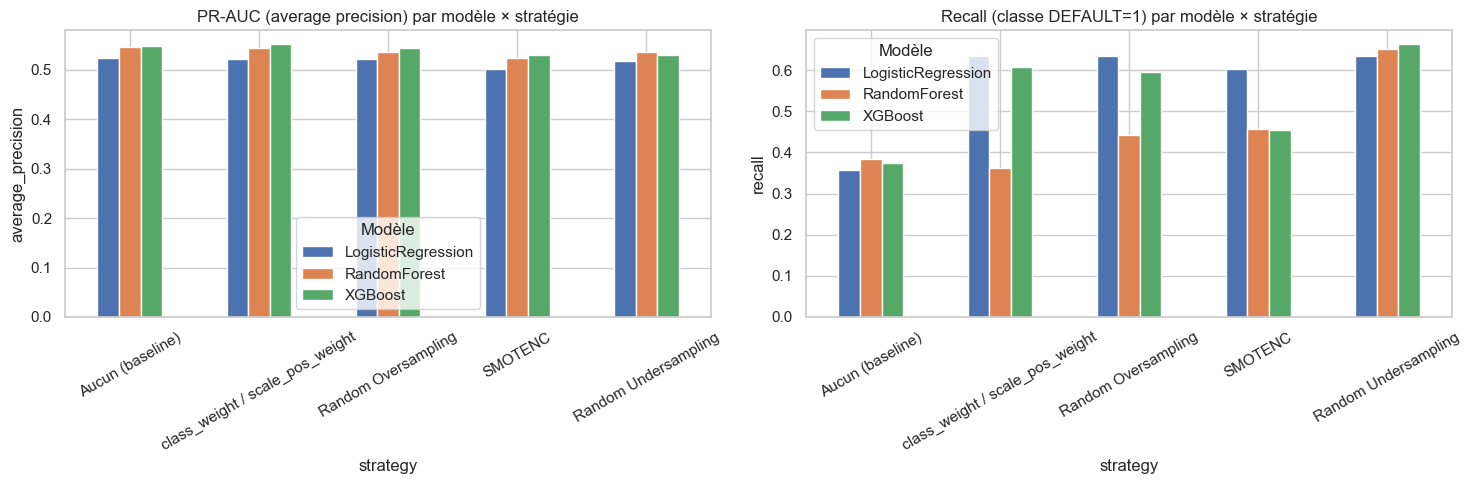

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pivot_ap = results_df.pivot(index="strategy", columns="model", values="average_precision")
pivot_ap = pivot_ap.loc[strategy_names]
pivot_ap.plot(kind="bar", ax=axes[0])
axes[0].set_title("PR-AUC (average precision) par modèle × stratégie")
axes[0].set_ylabel("average_precision")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Modèle")

pivot_recall = results_df.pivot(index="strategy", columns="model", values="recall")
pivot_recall = pivot_recall.loc[strategy_names]
pivot_recall.plot(kind="bar", ax=axes[1])
axes[1].set_title("Recall (classe DEFAULT=1) par modèle × stratégie")
axes[1].set_ylabel("recall")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Modèle")

plt.tight_layout()
plt.show()


## 15. Meilleure combinaison + calibration du seuil de décision

On sélectionne la combinaison modèle × stratégie avec le meilleur `average_precision` (PR-AUC) en
cross-validation — c'est la métrique la plus fiable ici, contrairement à l'accuracy.

Ensuite, le seuil de décision par défaut (0.5) n'a pas de raison d'être optimal pour un cas
d'usage bancaire où **rater un défaut de paiement (faux négatif) coûte plus cher qu'une fausse
alerte (faux positif)**. On calibre donc le seuil pour maximiser le **F2-score** (qui pondère le
rappel deux fois plus que la précision), en utilisant des probabilités **out-of-fold** obtenues
par cross-validation sur le train — jamais le test, pour éviter toute fuite. Le test set ne sert
qu'une seule fois, à la toute fin, pour confirmer le choix.


In [27]:
best_row = results_df.sort_values("average_precision", ascending=False).iloc[0]
best_model_name, best_strategy_name = best_row["model"], best_row["strategy"]
print("Meilleure combinaison (PR-AUC en CV) :")
print(best_row)

weighted = best_strategy_name == "class_weight / scale_pos_weight"
final_model = make_model(best_model_name, weighted=weighted)
final_resampler = make_resampler(best_strategy_name)
final_steps = [("resampler", final_resampler)]
if best_model_name == "LogisticRegression":
    final_steps.append(("scaler", StandardScaler()))
final_steps.append(("model", final_model))
final_pipeline = ImbPipeline(final_steps)


Meilleure combinaison (PR-AUC en CV) :
model                                        XGBoost
strategy             class_weight / scale_pos_weight
average_precision                           0.552364
f1                                          0.533227
recall                                       0.60859
precision                                   0.474482
roc_auc                                      0.77516
Name: 11, dtype: object


Meilleur seuil (max F2, out-of-fold sur train) : 0.258
  -> Precision=0.3190  Recall=0.8472  F2=0.6364
Pour comparaison, au seuil par défaut 0.5 :
  -> F2=0.5760


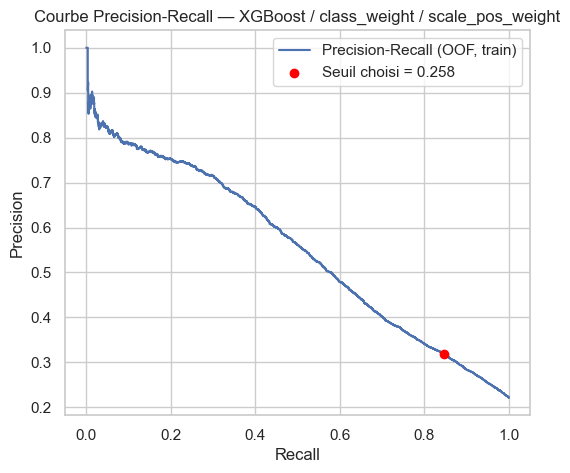

In [28]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, fbeta_score

# Probabilités out-of-fold sur le train (aucune fuite : chaque prédiction vient d'un modèle
# qui n'a jamais vu cette ligne pendant son propre entraînement).
oof_proba = cross_val_predict(
    final_pipeline, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)
# F2 : pondère le rappel 2x plus que la précision (rater un défaut coûte plus cher qu'une fausse alerte)
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-12)
best_idx = np.argmax(f2_scores[:-1])  # dernier point de precision_recall_curve n'a pas de seuil associé
best_threshold = thresholds[best_idx]

print(f"Meilleur seuil (max F2, out-of-fold sur train) : {best_threshold:.3f}")
print(f"  -> Precision={precisions[best_idx]:.4f}  Recall={recalls[best_idx]:.4f}  F2={f2_scores[best_idx]:.4f}")
print(f"Pour comparaison, au seuil par défaut 0.5 :")
f2_at_05 = fbeta_score(y_train, (oof_proba >= 0.5).astype(int), beta=2)
print(f"  -> F2={f2_at_05:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label="Precision-Recall (OOF, train)")
plt.scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5,
            label=f"Seuil choisi = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Courbe Precision-Recall — {best_model_name} / {best_strategy_name}")
plt.legend()
plt.show()


In [29]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score

# Un seul entraînement final sur tout le train, une seule évaluation sur le test jamais touché avant.
final_pipeline.fit(X_train, y_train)
test_proba = final_pipeline.predict_proba(X_test)[:, 1]

print(f"=== Évaluation finale sur le TEST set — {best_model_name} / {best_strategy_name} ===\n")
print(f"PR-AUC (average_precision) : {average_precision_score(y_test, test_proba):.4f}")
print(f"ROC-AUC                    : {roc_auc_score(y_test, test_proba):.4f}\n")

for label, thr in [("Seuil par défaut (0.5)", 0.5), (f"Seuil calibré ({best_threshold:.3f})", best_threshold)]:
    y_pred = (test_proba >= thr).astype(int)
    print(f"--- {label} ---")
    print(classification_report(y_test, y_pred, target_names=["0 - Pas de défaut", "1 - Défaut"], digits=3))
    print("Matrice de confusion (lignes=réel, colonnes=prédit) :")
    print(confusion_matrix(y_test, y_pred))
    print()


=== Évaluation finale sur le TEST set — XGBoost / class_weight / scale_pos_weight ===

PR-AUC (average_precision) : 0.5432
ROC-AUC                    : 0.7661

--- Seuil par défaut (0.5) ---
                   precision    recall  f1-score   support

0 - Pas de défaut      0.879     0.802     0.839      4673
       1 - Défaut      0.467     0.610     0.529      1327

         accuracy                          0.759      6000
        macro avg      0.673     0.706     0.684      6000
     weighted avg      0.788     0.759     0.770      6000

Matrice de confusion (lignes=réel, colonnes=prédit) :
[[3747  926]
 [ 517  810]]

--- Seuil calibré (0.258) ---
                   precision    recall  f1-score   support

0 - Pas de défaut      0.912     0.462     0.613      4673
       1 - Défaut      0.308     0.844     0.451      1327

         accuracy                          0.546      6000
        macro avg      0.610     0.653     0.532      6000
     weighted avg      0.779     0.546     

C:\Users\hp\AppData\Local\Temp\ipykernel_18388\4165756847.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


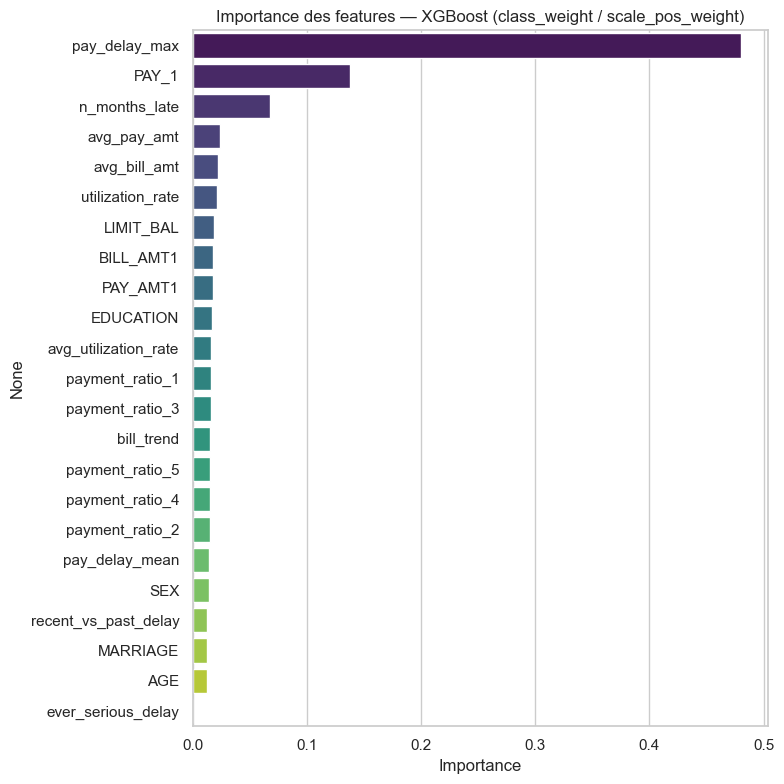

In [30]:
# Importance des features du modèle final (si applicable) — utile pour valider que le
# feature engineering de la partie 12 a bien apporté du signal.
fitted_model = final_pipeline.named_steps["model"]
if hasattr(fitted_model, "feature_importances_"):
    importances = pd.Series(fitted_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)
    plt.figure(figsize=(8, 8))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Importance des features — {best_model_name} ({best_strategy_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(fitted_model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
    print("Coefficients (valeur absolue triée) — modèle linéaire :")
    print(coefs)


## 16. Synthèse

- **Codes non documentés** (`EDUCATION` 0/5/6, `MARRIAGE` 0) : fusionnés dans la catégorie "autre"
  déjà prévue par le schéma UCI (`EDUCATION=4`, `MARRIAGE=3`) plutôt que supprimés ou imputés par
  le mode — aucune ligne perdue, aucune hypothèse non vérifiée. Vérification faite (section 11) :
  les taux de défaut de ces codes rares étaient hétérogènes (`EDUCATION=0` → 0% sur seulement 14
  clients) mais trop peu nombreux pour justifier une catégorie séparée après encodage.

- **Feature engineering — validé empiriquement** : le bloc brut de 18 colonnes mensuelles a été
  remplacé par des ratios/agrégats métier. Résultat concret (section 12) : `n_months_late`
  (corr. 0.398) et `ever_serious_delay` (0.363) dominent désormais `PAY_1` brut (0.325, la
  meilleure variable de l'EDA initiale) — le feature engineering a bien renforcé le signal, pas
  seulement réduit la redondance.

- **Comparaison des 15 combinaisons modèle × stratégie (5-fold CV, section 14)** — 3 enseignements
  nets et reproductibles sur ce dataset :
  1. `class_weight`/`scale_pos_weight` bat systématiquement le resampling pour les modèles à base
     d'arbres — **XGBoost + `scale_pos_weight` est la meilleure combinaison globale**
     (PR-AUC CV = 0.552, F1 = 0.533, Recall = 0.609), sans modifier aucune donnée.
  2. `SMOTENC` est la stratégie la plus faible pour les 3 modèles ici — l'interpolation synthétique
     ajoute du bruit plutôt que de l'info utile sur ce dataset (contre-intuitif mais net dans les
     chiffres, cf. tableau `results_df`).
  3. `LogisticRegression` plafonne à ~0.52 PR-AUC quelle que soit la stratégie de rééquilibrage —
     c'est un plafond de capacité du modèle linéaire, pas un problème de données.

- **`ID` client** : jamais utilisé comme feature ni comme base de rééquilibrage — le "problème"
  d'ID dupliqués évoqué initialement ne s'est jamais posé, puisque le rééquilibrage opère
  uniquement sur `X_train`/`y_train` (sans `ID`).

- **Évaluation finale (test set, jamais touché avant)** — XGBoost + `scale_pos_weight` :
  PR-AUC = 0.543, ROC-AUC = 0.766. Au seuil par défaut (0.5) : precision 46.7% / recall 61.0% sur
  la classe défaut, accuracy 75.9%.

- **Seuil calibré (F2, out-of-fold sur train) = 0.258** : fait grimper le recall à 84.7% mais fait
  chuter la precision à 30.8% et l'accuracy à 54.6% (plus de la moitié des clients test flagués
  "à risque"). **À nuancer** : l'argmax F2 pur est probablement trop agressif pour un déploiement
  réel — le bon seuil est une décision métier (coût d'un défaut manqué vs coût d'une fausse
  alerte/d'un contact client), pas une pure décision statistique. Recommandation : définir un
  coût explicite par erreur, ou viser un seuil intermédiaire (~0.35-0.40) plutôt que l'optimum F2
  brut.

**Prochaine étape du pipeline MLOps :** industrialiser cette logique (nettoyage → feature
engineering → split → pipeline `scale_pos_weight` XGBoost → seuil calibré selon coût métier) dans
un script Python réutilisable (hors notebook), avec le pipeline sérialisé (`joblib`/format natif
XGBoost) pour l'inférence en production.
